<a href="https://colab.research.google.com/github/chiamakachijioke/urban-mobility-optimisation/blob/main/01_Transport_Network_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transport Network Basics

This notebook creates a small transport network that will later be used to implement graph algorithms and optimisation methods.

#### The purpose of the libraries are

- math performs mathematical calculations.
- random will later generate random routes and starting solutions.
- numpy stores numerical information, especially the distance matrix.
- pandas presents your data in tables.
- matplotlib draws the locations and routes.

In [ ]:
# Import the necessary libraries
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

This means for egs: **Customer 1:**

is located at coordinate (20, 30);
requires four units of goods.

The coordinates provide the physical positions of the locations. The demand will later be used when I introduce vehicle-capacity constraints.

In [ ]:
# Create the locations
locations = {
    0: {"name": "Depot", "x": 50, "y": 50, "demand": 0},
    1: {"name": "Customer 1", "x": 20, "y": 30, "demand": 4},
    2: {"name": "Customer 2", "x": 80, "y": 25, "demand": 6},
    3: {"name": "Customer 3", "x": 15, "y": 75, "demand": 3},
    4: {"name": "Customer 4", "x": 65, "y": 80, "demand": 7},
    5: {"name": "Customer 5", "x": 40, "y": 20, "demand": 5},
    6: {"name": "Customer 6", "x": 90, "y": 60, "demand": 4},
    7: {"name": "Customer 7", "x": 30, "y": 90, "demand": 6},
    8: {"name": "Customer 8", "x": 70, "y": 45, "demand": 2},
    9: {"name": "Customer 9", "x": 45, "y": 70, "demand": 5},
}

Here, the original **"locations"** object is a **Python dictionary**. It is useful for accessing values in code, but it is not as easy to read.

The **DataFrame** displays the same information as a clear table.

So I now have two representations:

- **locations: useful for programming.**

- **locations_df: useful for viewing and analysing the data.**

In [ ]:
# Convert the data into a table

locations_df = pd.DataFrame.from_dict(locations, orient="index")

locations_df.index.name = "node"

locations_df


,name,x,y,demand
node,,,,
0,Depot,50,50,0
1,Customer 1,20,30,4
2,Customer 2,80,25,6
3,Customer 3,15,75,3
4,Customer 4,65,80,7
5,Customer 5,40,20,5
6,Customer 6,90,60,4
7,Customer 7,30,90,6
8,Customer 8,70,45,2


- **Depot → Node**
- **Customer → Node**
- **Road → Edge**
- **Distance → Edge weight**

Next, I only plot the locations. nothing more yet.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

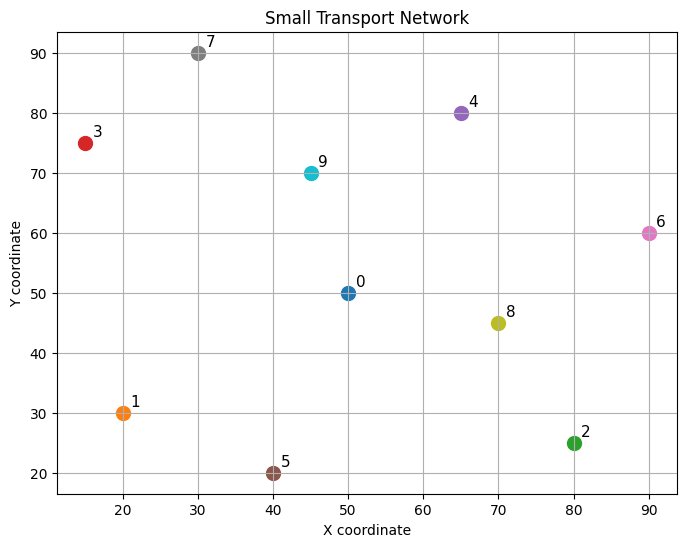

In [ ]:
# Visualise the locations

plt.figure(figsize=(8, 6))

for node, data in locations.items():
    plt.scatter(data["x"], data["y"], s=100)

    plt.text(
        data["x"] + 1,
        data["y"] + 1,
        str(node),
        fontsize=11
    )

plt.title("Small Transport Network")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True)
plt.show()

I remember that Euclidean distance is the straight-line distance between two points in Euclidean space. Derived directly from the Pythagorean theorem.

In 2D Space: For two points

    (x₁, y₁) and (x₂, y₂),

the distance d is:

$$\sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$


In [ ]:
# Create a distance function
# This is the straight-line distance between two locations.

def euclidean_distance(node_a, node_b, location_data):
    x1 = location_data[node_a]["x"]
    y1 = location_data[node_a]["y"]

    x2 = location_data[node_b]["x"]
    y2 = location_data[node_b]["y"]

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    return round(distance, 2)

In [ ]:
# Test it

distance_0_to_1 = euclidean_distance(0, 1, locations)

print("Distance from the depot to Customer 1:", distance_0_to_1)

Distance from the depot to Customer 1: 36.06


This is correct because:

    Depot = (50, 50)
    Customer 1 = (20, 30)

Therefore:

    x difference = 20 − 50 = −30
    y difference = 30 − 50 = −20

and:

    distance = √((-30)² + (-20)²)
            = √(900 + 400)
            = √1300
            ≈ 36.06

This is just me doing calculations, **not yet** an optimisation algorithm.

In [ ]:
# Create the distance matrix
# A distance matrix shows the distance between every pair of nodes.

number_of_nodes = len(locations)

distance_matrix = np.zeros((number_of_nodes, number_of_nodes))

for i in range(number_of_nodes):
    for j in range(number_of_nodes):
        distance_matrix[i][j] = euclidean_distance(i, j, locations)

In [ ]:
# Convert it into a readable table

distance_df = pd.DataFrame(
    distance_matrix,
    index=range(number_of_nodes),
    columns=range(number_of_nodes)
)

distance_df

,0,1,2,3,4,5,6,7,8,9
0,0.00,36.06,39.05,43.01,33.54,31.62,41.23,44.72,20.62,20.62
1,36.06,0.00,60.21,45.28,67.27,22.36,76.16,60.83,52.20,47.17
2,39.05,60.21,0.00,82.01,57.01,40.31,36.40,82.01,22.36,57.01
3,43.01,45.28,82.01,0.00,50.25,60.42,76.49,21.21,62.65,30.41
4,33.54,67.27,57.01,50.25,0.00,65.00,32.02,36.40,35.36,22.36
5,31.62,22.36,40.31,60.42,65.00,0.00,64.03,70.71,39.05,50.25
6,41.23,76.16,36.40,76.49,32.02,64.03,0.00,67.08,25.00,46.10
7,44.72,60.83,82.01,21.21,36.40,70.71,67.08,0.00,60.21,25.00
8,20.62,52.20,22.36,62.65,35.36,39.05,25.00,60.21,0.00,35.36
9,20.62,47.17,57.01,30.41,22.36,50.25,46.10,25.00,35.36,0.00


## NOTE:
Here, I see that the value in row i and column j is the distance from node i to node j. An example is below.
I also notice:
- The distance from a location to itself is zero.
- distance_matrix[0][1] = distance_matrix[1][0]
- The matrix gives us the cost of travelling directly between any two locations.

In [ ]:
# example:

print("Distance from node 2 to node 6:", distance_matrix[2][6])

Distance from node 2 to node 6: 36.4


# Next: Create and evaluate a simple route

Suppose a vehicle follows this route:

Depot → Customer 1 → Customer 5 → Customer 2 → Depot

In [ ]:
# I represent it as

route = [0, 1, 5, 2, 0]

In [ ]:
# create a function to calculate the route distance

def calculate_route_distance(route, matrix):
    total_distance = 0

    for i in range(len(route) - 1):
        current_node = route[i]
        next_node = route[i + 1]

        total_distance += matrix[current_node][next_node]

    return round(total_distance, 2)

In [ ]:
# Test it:

route_distance = calculate_route_distance(route, distance_matrix)

print("Route:", route)
print("Total route distance:", route_distance)

Route: [0, 1, 5, 2, 0]
Total route distance: 137.78


**Here, I notice that the function goes through each pair:**

0 → 1

1 → 5

5 → 2

2 → 0

**It adds all the distances together.**

This function is very important because it will later become my **objective function** evaluation

**The calculation is approximately:**

      0 → 1 = 36.06
      1 → 5 = 22.36
      5 → 2 = 40.31
      2 → 0 = 39.05

**Therefore:**

    36.06 + 22.36 + 40.31 + 39.05 = 137.78

**The optimisation problem will ask:**

Can we change the order of the customers and obtain a smaller total distance than 137.78?

 Because, at the moment, the function only evaluates the route you give it.

 It does not search for a better route.

In [ ]:
# Visualise the route

def plot_route(route, location_data):
    plt.figure(figsize=(8, 6))

    for node, data in location_data.items():
        plt.scatter(data["x"], data["y"], s=100)

        plt.text(
            data["x"] + 1,
            data["y"] + 1,
            str(node),
            fontsize=11
        )

    for i in range(len(route) - 1):
        current_node = route[i]
        next_node = route[i + 1]

        x_values = [
            location_data[current_node]["x"],
            location_data[next_node]["x"]
        ]

        y_values = [
            location_data[current_node]["y"],
            location_data[next_node]["y"]
        ]

        plt.plot(x_values, y_values)

    plt.title("Example Vehicle Route")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.grid(True)
    plt.show()

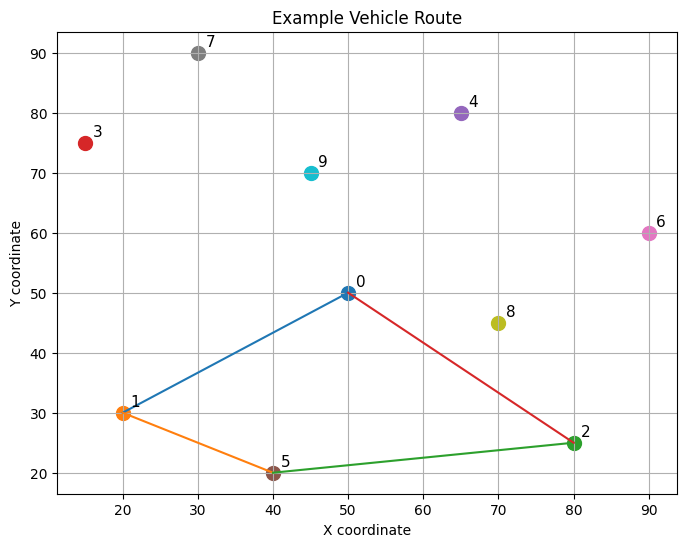

In [ ]:
plot_route(route, locations)

In [ ]:
# Calculate the total customer demand

total_demand = sum(
    data["demand"]
    for node, data in locations.items()
    if node != 0
)

print("Total customer demand:", total_demand)




Total customer demand: 42


In [ ]:
# Now suppose one vehicle has a capacity of:

vehicle_capacity = 20

In [ ]:
# Check whether one vehicle can serve all customers:

if total_demand <= vehicle_capacity:
    print("One vehicle can serve all customers.")
else:
    print("One vehicle cannot serve all customers.")

One vehicle cannot serve all customers.


**Since:**

    42 > 20

one vehicle cannot carry enough goods to serve all customers in one trip.

## **1st Constraint**

This introduces my first constraint:

    Demand carried by a vehicle ≤ Vehicle capacity

However, I have not yet divided the customers among multiple vehicles.

I have only checked whether one vehicle could serve everybody.

Since the total demand is **42** and one vehicle can carry **20**, I would need at least:

    42 ÷ 20 = 3

    vehicles or trips, assuming capacity is the only restriction

## **NOTE**
No algorithm has been used yet.

These are the building blocks needed before implementing an algorithm

# **NOTE II**

My current distance matrix assumes that every node is directly connected to every other node.

That means the network is a complete graph.

For example, it assumes that there is a direct connection from:

    0 to 1
    0 to 2
    0 to 3
    ...

    and from every other node to every node.

**That creates a problem when learning Dijkstra.**

Because I use straight-line Euclidean distances, the direct connection from a start node to a destination will normally be no longer than travelling through intermediate nodes.

**For example, Dijkstra may simply return:**

    0 → 6

    instead of:

    0 → 8 → 6

because the direct straight-line distance is already the shortest.

**Dijkstra becomes meaningful when not every pair of locations has a direct road.**

Therefore, next, I should create a sparse road network.

*For example:*

    0 is connected to 1, 8 and 9
    1 is connected to 3 and 5
    2 is connected to 5, 6 and 8
    3 is connected to 7 and 9
    4 is connected to 6, 7, 8 and 9

Then Dijkstra will need to search through possible paths.

*For example,*

    to travel from node 1 to node 6,

it may compare paths such as:

    1 → 5 → 2 → 6

          and:

    1 → 0 → 8 → 6

**It will then return whichever has the lowest total cost.**